In [1]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from IPython import display
from jiwer import wer

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
data_path = "/content/drive/MyDrive/LJSpeech-1.1"
wavs_path = f"{data_path}/wavs/"
metadata_path = f"{data_path}/metadata.csv"

metadata_df = pd.read_csv(metadata_path, sep="|", header=None, quoting=3)
metadata_df.columns = ["file_name", "transcription", "normalized_transcription"]
metadata_df = metadata_df[["file_name",
                            "normalized_transcription"]].sample(frac=1).reset_index(drop=True)
metadata_df = metadata_df.head(5000)

split = int(len(metadata_df) * 0.90)
df_train, df_val = metadata_df[:split], metadata_df[split:]

print("\n"+"="*50)
print(f"Training Samples: {len(df_train)}")
print(f"Validation Samples: {len(df_val)}")
print("="*50)

characters = [x for x in "abcdefghijklmnopqrstuvwxyz'?! "]
char_to_num = keras.layers.StringLookup(vocabulary=characters, oov_token="")
num_to_char = keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(),
                                        oov_token="", invert=True)

print(f"Character Set: {char_to_num.get_vocabulary()} (Total: {char_to_num.vocabulary_size()})\n")


Training Samples: 4500
Validation Samples: 500
Character Set: ['', np.str_('a'), np.str_('b'), np.str_('c'), np.str_('d'), np.str_('e'), np.str_('f'), np.str_('g'), np.str_('h'), np.str_('i'), np.str_('j'), np.str_('k'), np.str_('l'), np.str_('m'), np.str_('n'), np.str_('o'), np.str_('p'), np.str_('q'), np.str_('r'), np.str_('s'), np.str_('t'), np.str_('u'), np.str_('v'), np.str_('w'), np.str_('x'), np.str_('y'), np.str_('z'), np.str_("'"), np.str_('?'), np.str_('!'), np.str_(' ')] (Total: 31)



In [6]:
frame_length, frame_step, fft_length = 256, 160, 384

def encode_single_sample(wav_file, label):
    file = tf.io.read_file(wavs_path + wav_file + ".wav")
    audio, _ = tf.audio.decode_wav(file)
    audio = tf.squeeze(audio, axis=-1)
    audio = tf.cast(audio, tf.float32)
    spectrogram = tf.signal.stft(audio, frame_length=frame_length,
                                frame_step=frame_step, fft_length=fft_length)
    spectrogram = tf.abs(spectrogram) ** 0.5
    means, stddevs = tf.math.reduce_mean(spectrogram, 1, keepdims=True), \
                     tf.math.reduce_std(spectrogram, 1, keepdims=True)
    spectrogram = (spectrogram - means) / (stddevs + 1e-10)

    label = tf.strings.lower(label)
    label = tf.strings.unicode_split(label, input_encoding="UTF-8")
    label = char_to_num(label)
    return spectrogram, label

In [7]:
batch_size = 16

def prepare_dataset(df):
    dataset = tf.data.Dataset.from_tensor_slices((list(df["file_name"]),
                                                list(df["normalized_transcription"])))
    return (
        dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
        .padded_batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

train_dataset = prepare_dataset(df_train)
validation_dataset = prepare_dataset(df_val)

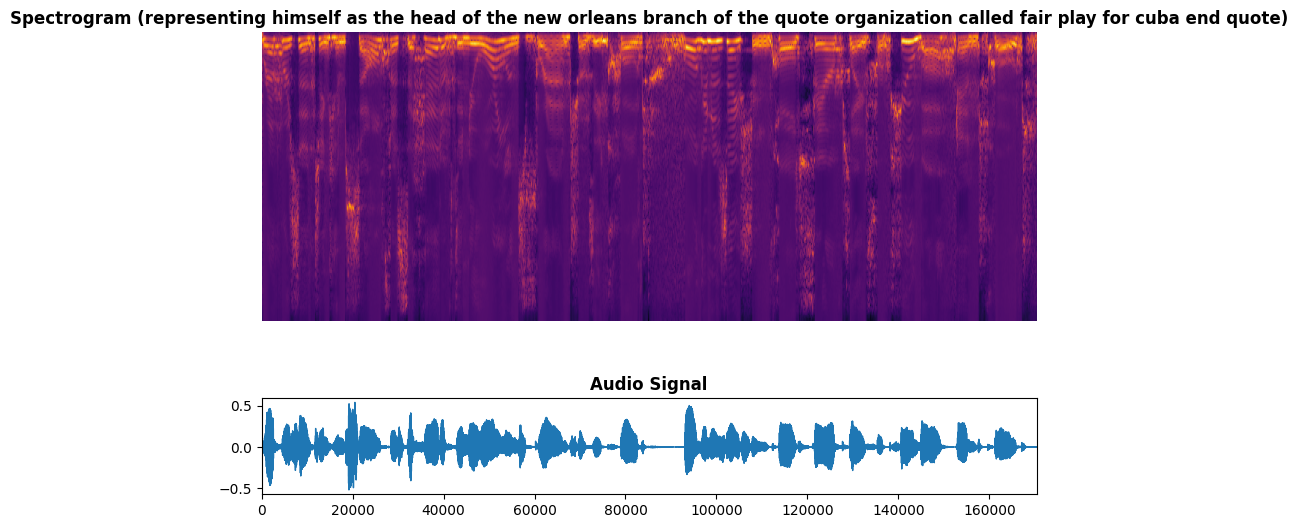

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})
plt.subplots_adjust(hspace=0.4)

for batch in train_dataset.take(1):
    spectrogram = batch[0][0].numpy()
    spectrogram = np.array([np.trim_zeros(x) for x in np.transpose(spectrogram)])
    label = batch[1][0]
    label_text = tf.strings.reduce_join(num_to_char(label)).numpy().decode("utf-8")

    axs[0].imshow(spectrogram, cmap="inferno", aspect="auto")
    axs[0].set_title(f"Spectrogram ({label_text})", fontsize=12, fontweight="bold")
    axs[0].axis("off")

    file = tf.io.read_file(wavs_path + list(df_train["file_name"])[0] + ".wav")
    audio, _ = tf.audio.decode_wav(file)
    audio = audio.numpy()

    axs[1].plot(audio, color='tab:blue', lw=1)
    axs[1].set_title("Audio Signal", fontsize=12, fontweight="bold")
    axs[1].set_xlim(0, len(audio))

    display.display(display.Audio(np.transpose(audio), rate=16000))
plt.show()

In [9]:
def CTCLoss(y_true, y_pred):
    """Computes the CTC loss."""
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones((batch_len, 1), dtype=tf.int64)
    label_length = label_length * tf.ones((batch_len, 1), dtype=tf.int64)

    return keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

In [10]:
def build_model(input_dim, output_dim, rnn_units=256, rnn_layers=3):
    input_spectrogram = layers.Input((None, input_dim), name="input")
    x = layers.Reshape((-1, input_dim, 1), name="expand_dim")(input_spectrogram)
    x = layers.Conv2D(16, (7, 31), (2, 2), padding="same", use_bias=False,
                      name="conv_1")(x)
    x = layers.BatchNormalization(name="conv_1_bn")(x)
    x = layers.ReLU(name="conv_1_relu")(x)
    x = layers.Conv2D(16, (7, 15), (1, 2), padding="same", use_bias=False,
                      name="conv_2")(x)
    x = layers.BatchNormalization(name="conv_2_bn")(x)
    x = layers.ReLU(name="conv_2_relu")(x)
    x = layers.Reshape((-1, x.shape[-2] * x.shape[-1]))(x)

    for i in range(rnn_layers):
        recurrent = layers.GRU(rnn_units, return_sequences=True, name=f"gru_{i+1}")
        x = layers.Bidirectional(recurrent, name=f"bidirectional_{i+1}")(x)
        if i == rnn_layers - 1:
            x = layers.Dropout(0.3)(x)
    x = layers.Dense(rnn_units, activation="relu", name="dense_1")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(output_dim + 1, activation="softmax")(x)

    model = keras.Model(input_spectrogram, output, name="DeepSpeech2_Small")
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
                  loss=CTCLoss)
    return model

model = build_model(fft_length // 2 + 1, char_to_num.vocabulary_size())
model.summary(line_length=120)

Model: "DeepSpeech2_Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input (InputLayer)                                  │ (None, None, 193)                      │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ expand_dim (Reshape)                                │ (None, None, 193, 1)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv_1 (Conv2D)                                     │ (None, None, 97, 16)                   │                 3,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv_1_bn (BatchNormalization)                      │ (None, None, 97, 16)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv_1_relu (ReLU)                                  │ (None, None, 97, 16)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv_2 (Conv2D)                                     │ (None, None, 49, 16)                   │                26,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv_2_bn (BatchNormalization)                      │ (None, None, 49, 16)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv_2_relu (ReLU)                                  │ (None, None, 49, 16)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ reshape (Reshape)                                   │ (None, None, 784)                      │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ bidirectional_1 (Bidirectional)                     │ (None, None, 512)                      │             1,600,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ bidirectional_2 (Bidirectional)                     │ (None, None, 512)                      │             1,182,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ bidirectional_3 (Bidirectional)                     │ (None, None, 512)                      │             1,182,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout (Dropout)                                   │ (None, None, 512)                      │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dense_1 (Dense)                                     │ (None, None, 256)                      │               131,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_1 (Dropout)                                 │ (None, None, 256)                      │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dense (Dense)                                       │ (None, None, 32)                       │                 8,
└─────────────────────────────────────────────────────┴─

 Total params: 4,135,984 (15.78 MB)

 Trainable params: 4,135,920 (15.78 MB)

 Non-trainable params: 64 (256.00 B)

In [11]:
def decode_batch_predictions(pred):
    """Decodes predictions into text."""
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = keras.backend.ctc_decode(pred, input_length=input_len,
                                      greedy=True)[0][0]
    return [tf.strings.reduce_join(num_to_char(r)).numpy().decode("utf-8") for r in results]

In [12]:
class CallbackEval(keras.callbacks.Callback):
    """Custom callback to evaluate WER at each epoch."""

    def __init__(self, dataset, num_examples=5):
        super().__init__()
        self.dataset = dataset
        self.num_examples = num_examples

    def on_epoch_end(self, epoch, logs=None):
        predictions, targets = [], []
        for batch in self.dataset:
            X, y = batch
            batch_predictions = decode_batch_predictions(self.model.predict(X))
            predictions.extend(batch_predictions)
            targets.extend([tf.strings.reduce_join(num_to_char(l)).numpy().decode("utf-8") for l in y])

        print("\n" + "="*50)
        print(f"Word Error Rate (WER) at epoch {epoch+1}: {wer(targets, predictions):.4f}")
        print("="*50)

        print("\nSample Predictions:")
        for i in range(min(self.num_examples, len(targets))):
            print(f"Original:    {targets[i]}")
            print(f"Predicted: {predictions[i]}")
            print("-"*50)
        print("\n")

In [14]:
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=10,
                    callbacks=[CallbackEval(validation_dataset)])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 629ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━

In [15]:
final_model_path = "final_model.h5"
model.save(final_model_path)

print(f"\nFinal model saved at: {final_model_path}")


Final model saved at: final_model.h5


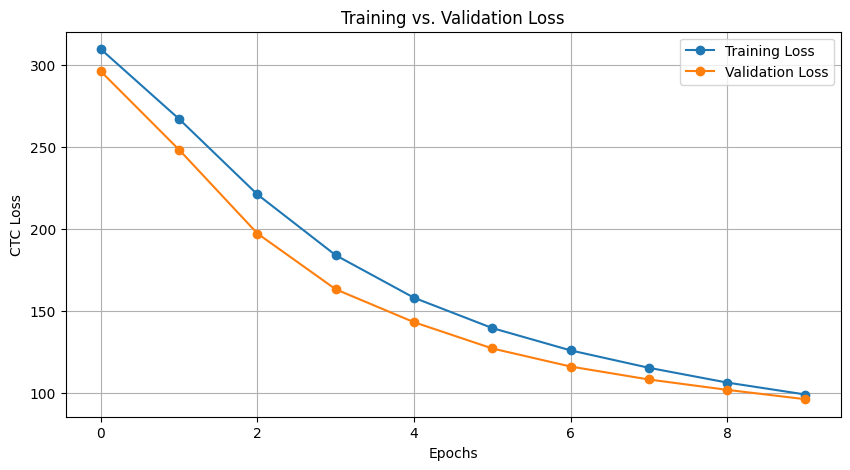

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss", marker="o")
plt.plot(history.history["val_loss"], label="Validation Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("CTC Loss")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import os
from tensorflow import keras
import tensorflow as tf
import numpy as np

def CTCLoss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones((batch_len, 1), dtype=tf.int64)
    label_length = label_length * tf.ones((batch_len, 1), dtype=tf.int64)
    return keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)

model = keras.models.load_model("final_model.h5", custom_objects={"CTCLoss": CTCLoss})

print("Model loaded successfully!")

Model loaded successfully!


In [18]:
frame_length, frame_step, fft_length = 256, 160, 384

def preprocess_audio(file_path):
    file = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(file)
    audio = tf.squeeze(audio, axis=-1)
    audio = tf.cast(audio, tf.float32)
    spectrogram = tf.signal.stft(audio, frame_length=frame_length,
                                frame_step=frame_step, fft_length=fft_length)
    spectrogram = tf.abs(spectrogram) ** 0.5
    means, stddevs = tf.math.reduce_mean(spectrogram, 1, keepdims=True), \
                     tf.math.reduce_std(spectrogram, 1, keepdims=True)
    spectrogram = (spectrogram - means) / (stddevs + 1e-10)
    spectrogram = tf.expand_dims(spectrogram, axis=0)
    return spectrogram

characters = [x for x in "abcdefghijklmnopqrstuvwxyz'?! "]
char_to_num = keras.layers.StringLookup(vocabulary=characters, oov_token="")
num_to_char = keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(),
                                        oov_token="", invert=True)

def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = keras.backend.ctc_decode(pred, input_length=input_len,
                                      greedy=True)[0][0]
    return [tf.strings.reduce_join(num_to_char(r)).numpy().decode("utf-8") for r in results]

def transcribe_audio(file_path):
    spectrogram = preprocess_audio(file_path)
    predictions = model.predict(spectrogram)
    decoded_text = decode_batch_predictions(predictions)[0]
    return decoded_text

In [23]:
audio_file_path = os.path.join("/content/drive/MyDrive/LJSpeech-1.1", "wavs", "LJ014-0086.wav")
transcription = transcribe_audio(audio_file_path)

print(f"Transcription: {transcription}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Transcription: this jo was not completed til the folowin da as the phol ha to be alargd and the oly to they had was a dustc
